In [1]:
import pandas as pd
import numpy as np
import torch
import os
import sys
from tqdm import tqdm, trange

sys.path.append("../../")
import biked_commons
from biked_commons.design_evaluation.design_evaluation import *
from biked_commons.resource_utils import split_datasets_path
from biked_commons.conditioning import conditioning
from biked_commons.design_evaluation.scoring import *
from biked_commons.benchmark_models import generative_modeling_utils, benchmarking_utils


c:\Users\Lyler\mambaforge\envs\torch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import importlib
importlib.reload(generative_modeling_utils)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data = pd.read_csv(split_datasets_path("bike_bench.csv"), index_col=0)
data_tens = torch.tensor(data.values, dtype=torch.float32, device=device)

scaler = generative_modeling_utils.TorchScaler(data_tens)

scaled_data_tens = scaler.scale(data_tens)

continuous_conditioning = generative_modeling_utils.sample_continuous(len(scaled_data_tens))


In [3]:
importlib.reload(generative_modeling_utils)
aux_fn = generative_modeling_utils.get_diversity_loss_fn(scaler, data.columns, 
                                                         diversity_weight = 1.0, 
                                                         score_weight = 0.2, 
                                                         constraint_vs_objective_weight = 10, 
                                                         constraint_falloff = 10, 
                                                         dpp_batch = 16, 
                                                         device = device)

thickness_params = ["Wall thickness Down tube", "Wall thickness Bottom Bracket", "Wall thickness Seat tube", "Wall thickness Top tube", "Wall thickness Chain stay", "Wall thickness Seat stay", "Wall thickness Head tube"]
diameter_params = ["dtd", "BB diameter", "Seat tube diameter", "dtd", "csd", "ssd", "Head tube diameter"]
thickness_params = thickness_params + diameter_params
thickness_indices = [data.columns.get_loc(param) for param in thickness_params]
thickened_data = scaled_data_tens.clone()
thickened_data[:, thickness_indices] += 2

diversified_data = scaled_data_tens.clone() *1.1


bs = 4500
print(aux_fn(scaled_data_tens[:bs], continuous_conditioning[:bs]))
print(aux_fn(thickened_data[:bs], continuous_conditioning[:bs]))
print(aux_fn(diversified_data[:bs], continuous_conditioning[:bs]))

c:\Users\Lyler\Documents\biked-commons\src\biked_commons\benchmark_models\../..\biked_commons\benchmark_models\generative_modeling_utils.py:138: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\TensorShape.cpp:3687.)
  Q = torch.matmul(scores_batch, scores_batch.T)


(tensor(3.7352, device='cuda:0', grad_fn=<MulBackward0>), {'CSR': tensor(0.0225, device='cuda:0'), 'MCS': tensor(4.1845, device='cuda:0', grad_fn=<MeanBackward0>)})
(tensor(3.5054, device='cuda:0', grad_fn=<MulBackward0>), {'CSR': tensor(0.3508, device='cuda:0'), 'MCS': tensor(2.3761, device='cuda:0', grad_fn=<MeanBackward0>)})
(tensor(3.4503, device='cuda:0', grad_fn=<MulBackward0>), {'CSR': tensor(0.0024, device='cuda:0'), 'MCS': tensor(25.4783, device='cuda:0', grad_fn=<MeanBackward0>)})


In [58]:
# train_params = batch_size, disc_lr, gen_lr, noise_dim, num_epochs, n_hidden, layer_size
importlib.reload(generative_modeling_utils)

model = "VAE"

noise_dim = 10
batch_size = 512
train_params = (batch_size, 0.0003, 0.0003, noise_dim, 10, 2, 256)
D, G, generate_fn = generative_modeling_utils.train_model(scaled_data_tens, model, train_params, aux_fn, device)


c:\Users\Lyler\Documents\biked-commons\src\biked_commons\benchmark_models\../..\biked_commons\benchmark_models\generative_modeling_utils.py:524: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data = torch.tensor(data).float()
100%|██████████| 87/87 [02:17<00:00,  1.57s/it, L_KL=0.3812, L_R=1.2316, L_tot=9.0203, L_aux=7.7125, CSR=0.3418, MCS=10.2026] 


In [59]:
def predict(cond_test):
    cond_test = cond_test.to(device)
    predictions = []
    #use batch size
    for i in range(0, len(cond_test), batch_size):
        batch = cond_test[i:i + batch_size]
        with torch.no_grad():
            pred = generate_fn(D, G, batch, noise_dim, device=device)
            pred = scaler.unscale(pred)
            predictions.append(pred)
    predictions = torch.concat(predictions, axis=0)
    return predictions


In [60]:
continuous_condition = generative_modeling_utils.sample_continuous(10000, split="test", randomize=False)
condition = generative_modeling_utils.parse_continuous_condition(continuous_condition)
predictions = predict(continuous_condition).detach()

main_scores, detailed_scores = benchmarking_utils.evaluate_cond(predictions, f"{model}-PA", data.columns, device=device)

print("Main scores: ", main_scores)
print("Detailed scores: ", detailed_scores)


Main scores:  Hypervolume                     0.250231
Constraint Satisfaction Rate    0.096300
Maximum Mean Discrepancy        0.098798
dtype: float64
Detailed scores:  Min Objective Score: Usability Score - 0 to 1                                                                0.034782
Min Objective Score: Drag Force                                                                             17.765816
Min Objective Score: Knee Angle Error                                                                        0.000000
Min Objective Score: Hip Angle Error                                                                        52.261124
Min Objective Score: Arm Angle Error                                                                        87.307190
Min Objective Score: Cosine Distance to Embedding                                                            0.000061
Min Objective Score: Mass                                                                                    4.821455
Min 

In [7]:
from biked_commons.design_evaluation import scoring 
from biked_commons.design_evaluation import design_evaluation
importlib.reload(design_evaluation)
importlib.reload(scoring)
evaluator, requirement_names, requirement_types = construct_tensor_evaluator(get_standard_evaluations(device), data.columns)

In [8]:

weights = scoring.get_ref_point(evaluator, requirement_names, requirement_names, reduction="meanabs")
weights = torch.tensor(weights, dtype=torch.float32, device=device)


In [46]:
importlib.reload(one_hot_encoding)
preds_df = pd.DataFrame(predictions.cpu().numpy(), columns=data.columns)
# preds_df["SEATSTAYbrdgCheck"] = np.zeros(preds_df.shape[0])
# preds_df["CHAINSTAYbrdgCheck"] = np.zeros(preds_df.shape[0])
# preds_df["MATERIAL OHCLASS: STEEL"] = np.ones(preds_df.shape[0])
# preds_df["MATERIAL OHCLASS: TITANIUM"] = np.zeros(preds_df.shape[0])
# preds_df["MATERIAL OHCLASS: ALUMINUM"] = np.zeros(preds_df.shape[0])
preds_categorical = one_hot_encoding.decode_to_mixed(preds_df)

preds_recont = one_hot_encoding.encode_to_continuous(preds_categorical)
preds_recont_tens = torch.tensor(preds_recont.values, dtype=torch.float32, device=device)

In [47]:
# diff = preds_recont - preds_df
preds_recont.iloc[:, 60:70]

,Down tube diameter,Seatpost LENGTH,MATERIAL OHCLASS: ALUMINIUM,MATERIAL OHCLASS: BAMBOO,MATERIAL OHCLASS: CARBON,MATERIAL OHCLASS: OTHER,MATERIAL OHCLASS: STEEL,MATERIAL OHCLASS: TITANIUM,Dropout spacing style OHCLASS: 0,Dropout spacing style OHCLASS: 1
0,35.145271,303.789001,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,35.061905,285.146667,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,36.281231,318.547272,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,37.104839,301.560059,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,34.061295,290.683350,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
9995,36.241356,285.425079,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
9996,36.100601,292.477905,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
9997,37.405052,272.531250,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
9998,38.176132,311.014130,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [48]:
preds_df.iloc[:, 60:70]

,Down tube diameter,Seatpost LENGTH,MATERIAL OHCLASS: ALUMINIUM,MATERIAL OHCLASS: BAMBOO,MATERIAL OHCLASS: CARBON,MATERIAL OHCLASS: OTHER,MATERIAL OHCLASS: STEEL,MATERIAL OHCLASS: TITANIUM,Dropout spacing style OHCLASS: 0,Dropout spacing style OHCLASS: 1
0,35.145271,303.789001,0.009644,-0.026454,0.102210,0.002753,0.694033,-0.020481,0.055268,0.150771
1,35.061905,285.146667,0.003052,-0.034345,0.213180,0.040533,0.822481,-0.015267,0.081022,0.355391
2,36.281231,318.547272,-0.114048,0.024869,-0.009674,0.041917,0.788084,-0.025421,0.141438,0.141478
3,37.104839,301.560059,-0.046212,-0.003096,0.221647,0.054209,0.533050,0.082721,0.057029,0.321639
4,34.061295,290.683350,-0.033960,-0.030107,0.088399,0.009727,0.576114,0.017120,0.063256,0.193978
...,...,...,...,...,...,...,...,...,...,...
9995,36.241356,285.425079,-0.066234,0.019845,0.132401,0.077137,0.719209,0.062776,0.234120,0.239429
9996,36.100601,292.477905,-0.106199,-0.061283,0.218080,-0.018298,0.617880,0.069347,0.036519,0.185833
9997,37.405052,272.531250,-0.047815,-0.015592,0.305765,0.078501,0.572818,0.173659,0.202837,0.393288
9998,38.176132,311.014130,0.039392,0.013784,0.212219,0.062655,0.460707,0.135018,0.092432,0.212453


In [52]:
preds_recont_tens

tensor([[413.9400,  41.3060, 578.4579,  ...,   0.0000,   0.0000,   1.0000],
        [420.6117,  40.8763, 570.2506,  ...,   0.0000,   1.0000,   0.0000],
        [382.6478,  49.3308, 557.3697,  ...,   0.0000,   0.0000,   1.0000],
        ...,
        [398.7849,  51.6202, 563.3616,  ...,   0.0000,   1.0000,   0.0000],
        [384.3450,  47.4120, 604.1107,  ...,   0.0000,   1.0000,   0.0000],
        [405.2591,  46.8032, 573.9130,  ...,   0.0000,   1.0000,   0.0000]],
       device='cuda:0')

In [ ]:
print(evaluator(predictions, condition))
print(evaluator(preds_recont_tens, condition))

tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         1.7881e-07],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        ...,
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         7.7486e-07],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         5.9605e-07],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         1.0836e-04]], device='cuda:0', grad_fn=<SubBackward0>)



In [55]:
scores = evaluator(preds_recont_tens, condition)
scaled_scores = scores / weights
score_df = pd.DataFrame(scaled_scores.detach().cpu().numpy(), columns=requirement_names)

In [56]:
torch.sum(torch.all(scaled_scores.detach().cpu()[:, 10:]<=0, axis=1))

tensor(1078)

In [57]:
score_df.iloc[:, 10:]

,Planar Safety Factor,Eccentric Safety Factor,Saddle height too small,Seat post too short,Head tube lower extension too great,Head tube length too great,Certain parameters must be positive,Chain stay should be greater than wheel radius,Chain stay should be greater than BB,Seat stay should be greater than wheel radius,Down tube must reach head tube,The pedal shouldn't intersect the front wheel,The crank shouldn't hit the ground when it is in its lower position,RGB value should be less than 255,Predicted Frame Validity
0,0.183004,0.107460,-1.127510,-0.915271,-0.912056,-0.831086,0.0,-1.031386,-1.015976,-1.401559,-0.914958,-1.047193,-1.025892,-0.860037,-1.002460
1,0.106495,-0.236967,-1.168980,-0.753742,-0.868196,-0.816791,0.0,-1.201220,-1.035338,-1.442072,-0.969463,-1.227704,-0.966137,-1.017327,-1.002460
2,0.159357,0.143793,-0.528410,-1.561488,-0.877338,-0.682006,0.0,-0.745325,-0.908780,-1.530684,-1.016996,-1.286980,-0.884571,-0.885905,-1.002460
3,-0.293817,0.025469,-1.063537,-0.959055,-1.067446,-1.057436,0.0,-0.724946,-0.938858,-1.065412,-0.901169,-0.994425,-0.996860,-1.093450,-1.002460
4,-0.112787,-0.111544,-1.041025,-0.907567,-0.933086,-0.853342,0.0,-0.934870,-0.981137,-1.449260,-0.924965,-1.208442,-0.982521,-0.971179,-1.002460
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.113435,0.063232,-0.891290,-1.009774,-1.077757,-1.076987,0.0,-0.896054,-0.984764,-1.346125,-1.116599,-1.324799,-1.022300,-1.153831,-1.002460
9996,1.070486,0.304488,-1.052837,-0.908649,-0.735949,-0.527279,0.0,-1.013812,-0.974893,-1.225663,-0.832765,-0.961425,-0.905292,-0.911386,-1.002460
9997,0.378636,0.118403,-0.967039,-0.854971,-0.912302,-0.841000,0.0,-0.864421,-0.946535,-0.858331,-0.986440,-1.032275,-0.921107,-1.241817,-1.002460
9998,0.432685,0.376521,-1.009146,-1.071507,-1.218989,-1.280325,0.0,-0.559577,-0.918639,-0.788074,-0.892889,-0.714269,-1.050610,-1.072120,-1.002460


In [14]:
score_df.iloc[:, 10:]

,Planar Safety Factor,Eccentric Safety Factor,Saddle height too small,Seat post too short,Head tube lower extension too great,Head tube length too great,Certain parameters must be positive,Chain stay should be greater than wheel radius,Chain stay should be greater than BB,Seat stay should be greater than wheel radius,Down tube must reach head tube,The pedal shouldn't intersect the front wheel,The crank shouldn't hit the ground when it is in its lower position,RGB value should be less than 255,Predicted Frame Validity
0,-0.029202,-0.077874,-1.127510,-0.915271,-0.912056,-0.831086,0.0,-1.031386,-1.015976,-1.401559,-0.914958,-1.047193,-1.025892,-0.860037,-1.002460
1,-0.382009,-0.333400,-1.168980,-0.753742,-0.868196,-0.816791,0.0,-1.201220,-1.035338,-1.442072,-0.969463,-1.227704,-0.966137,-1.017327,-1.002460
2,0.062581,-0.023121,-0.528410,-1.561488,-0.877338,-0.682006,0.0,-0.745325,-0.908780,-1.530684,-1.016996,-1.286980,-0.884571,-0.885905,-1.002460
3,0.108471,0.149584,-1.063537,-0.959055,-1.067446,-1.057436,0.0,-0.724946,-0.938858,-1.065412,-0.901169,-0.994425,-0.996860,-1.093450,-1.002460
4,-0.072901,-0.058968,-1.041025,-0.907567,-0.933086,-0.853342,0.0,-0.934870,-0.981137,-1.449260,-0.924965,-1.208442,-0.982521,-0.971179,-1.002460
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,-0.036081,-0.257128,-0.891290,-1.009774,-1.077757,-1.076987,0.0,-0.896054,-0.984764,-1.346125,-1.116599,-1.324799,-1.022300,-1.153831,-1.002459
9996,1.000530,0.247924,-1.052837,-0.908649,-0.735949,-0.527279,0.0,-1.013812,-0.974893,-1.225663,-0.832765,-0.961425,-0.905292,-0.911386,-1.002460
9997,-0.050161,-0.040141,-0.967039,-0.854971,-0.912302,-0.841000,0.0,-0.864421,-0.946535,-0.858331,-0.986440,-1.032275,-0.921107,-1.241817,-1.002459
9998,-0.213524,-0.005034,-1.009146,-1.071507,-1.218989,-1.280325,0.0,-0.559577,-0.918639,-0.788074,-0.892889,-0.714269,-1.050610,-1.072120,-1.002459


In [15]:
score_df.iloc[:, 10:]

,Planar Safety Factor,Eccentric Safety Factor,Saddle height too small,Seat post too short,Head tube lower extension too great,Head tube length too great,Certain parameters must be positive,Chain stay should be greater than wheel radius,Chain stay should be greater than BB,Seat stay should be greater than wheel radius,Down tube must reach head tube,The pedal shouldn't intersect the front wheel,The crank shouldn't hit the ground when it is in its lower position,RGB value should be less than 255,Predicted Frame Validity
0,-0.029202,-0.077874,-1.127510,-0.915271,-0.912056,-0.831086,0.0,-1.031386,-1.015976,-1.401559,-0.914958,-1.047193,-1.025892,-0.860037,-1.002460
1,-0.382009,-0.333400,-1.168980,-0.753742,-0.868196,-0.816791,0.0,-1.201220,-1.035338,-1.442072,-0.969463,-1.227704,-0.966137,-1.017327,-1.002460
2,0.062581,-0.023121,-0.528410,-1.561488,-0.877338,-0.682006,0.0,-0.745325,-0.908780,-1.530684,-1.016996,-1.286980,-0.884571,-0.885905,-1.002460
3,0.108471,0.149584,-1.063537,-0.959055,-1.067446,-1.057436,0.0,-0.724946,-0.938858,-1.065412,-0.901169,-0.994425,-0.996860,-1.093450,-1.002460
4,-0.072901,-0.058968,-1.041025,-0.907567,-0.933086,-0.853342,0.0,-0.934870,-0.981137,-1.449260,-0.924965,-1.208442,-0.982521,-0.971179,-1.002460
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,-0.036081,-0.257128,-0.891290,-1.009774,-1.077757,-1.076987,0.0,-0.896054,-0.984764,-1.346125,-1.116599,-1.324799,-1.022300,-1.153831,-1.002459
9996,1.000530,0.247924,-1.052837,-0.908649,-0.735949,-0.527279,0.0,-1.013812,-0.974893,-1.225663,-0.832765,-0.961425,-0.905292,-0.911386,-1.002460
9997,-0.050161,-0.040141,-0.967039,-0.854971,-0.912302,-0.841000,0.0,-0.864421,-0.946535,-0.858331,-0.986440,-1.032275,-0.921107,-1.241817,-1.002459
9998,-0.213524,-0.005034,-1.009146,-1.071507,-1.218989,-1.280325,0.0,-0.559577,-0.918639,-0.788074,-0.892889,-0.714269,-1.050610,-1.072120,-1.002459


In [16]:

data.iloc[:, 25]

1       0.0
2       0.0
3       0.0
4       0.0
5       0.0
       ... 
4796    1.0
4797    0.0
4798    1.0
4799    1.0
4800    1.0
Name: CHAINSTAYbrdgCheck, Length: 4498, dtype: float64

(array([2767.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        1731.]),
 array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
        0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
        0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29

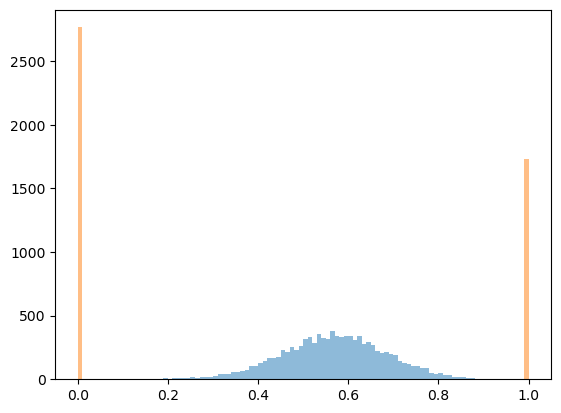

In [17]:
import matplotlib.pyplot as plt
r = predictions[:, 25].cpu().detach().numpy()
s = data.iloc[:, 25].values
lo, hi = np.min([r.min(), s.min()]), np.max([r.max(), s.max()])
bins = np.linspace(lo, hi, 101)
plt.hist(r, bins=bins, alpha=0.5, label='Predictions')
plt.hist(s, bins=bins, alpha=0.5, label='Data')